## **Utilizando pandas + matplotlib**

In [1]:
!pip install pandas 
!pip install matplotlib

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    --------------------------------------- 0.3/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 1.1 MB/s eta 0:00:10
   -- ------------------------------------- 0.8/11.0 MB 1.2 MB/s eta 0:00:09
   --- ------------------------------------ 1.0/11.0 MB 1.2 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/11.0 MB 1.3 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/11.0 MB 1.2 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/11.0 MB 1.2 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/11.0 MB 1.1 MB/s eta 0:00:09
   ------- -------------------------------- 2.1/11.0 MB 1.0 MB/s eta 0:00:09
   -------- ------------------------------- 2.4/11.0 MB 1.0 MB/s eta 0:00:09
   -------- ------------------------------- 2.4/11.0 MB 1.0 MB/s eta 0:00:09
   --------- -------


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 848.1 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.1 MB 880.0 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.1 MB 880.0 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.1 MB 857.2 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.1 MB 880.5 kB/s eta 0:00:08
   ------ --------------------------------- 1.3/8.1 MB 880.5 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.1 MB 867.4 kB/s eta 0:00:08
   --------- ------------------------------ 1.8/8.1 MB 852.8 kB/s eta 0:00:08
   --------- ------------------------------ 1.8/8.1 MB 852.8 kB/s eta 0:00:08
   ---------- ----------------------------- 2.1/8.1 MB 812.3 kB/s eta 0:00:08
   ----------


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

try:
    df_vendas = pd.read_csv('VendasGlobais.csv')
    df_fornecedores = pd.read_csv('Fornecedores.csv')
    df_transportadoras = pd.read_csv('Transportadoras.csv')
    df_vendedores = pd.read_csv('Vendedores.csv')
except FileNotFoundError as e:
    print(f"Erro: Um ou mais arquivos CSV não foram encontrados. Certifique-se de que os arquivos estão no mesmo diretório do script. Detalhes: {e}")
    exit()

df_vendas['Data'] = pd.to_datetime(df_vendas['Data'], format='%d/%m/%Y')

In [ ]:
# Top 10 Clientes (Gráfico de Barras)
top_clientes = df_vendas.groupby('ClienteNome')['Vendas'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x=top_clientes.index, height=top_clientes.values, color='skyblue')
ax.set_title('Top 10 Clientes por Vendas', fontsize=16)
ax.set_xlabel('Cliente', fontsize=12)
ax.set_ylabel('Total de Vendas ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Data
2009     87666.2940
2010    370788.5561
2011    641719.4091
2012    682973.4414
Name: Vendas, dtype: float64


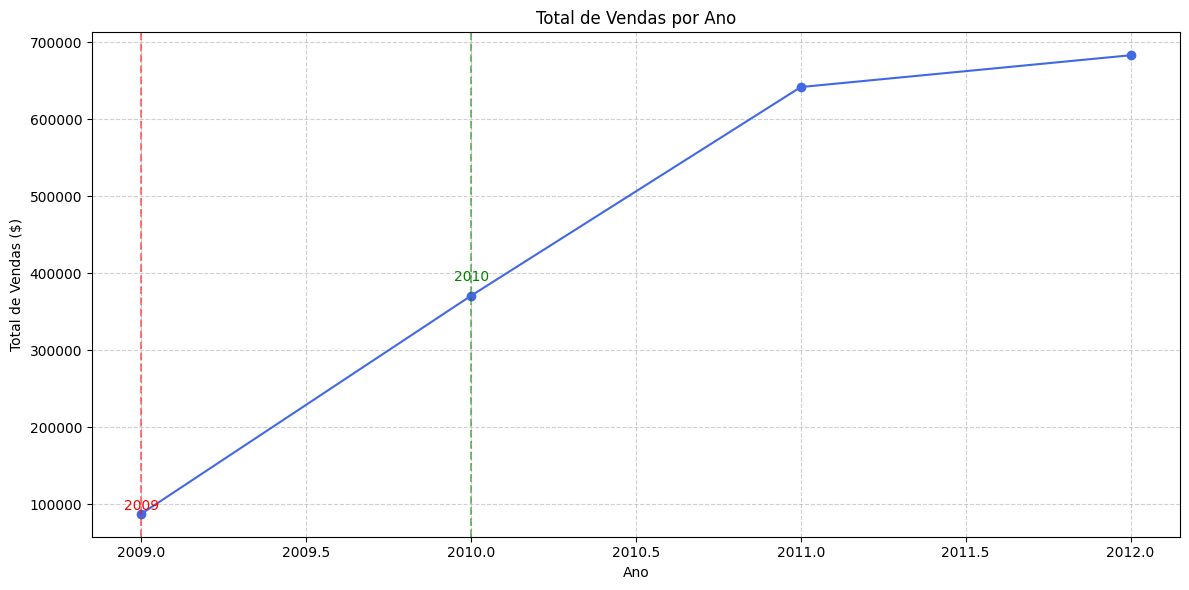

In [ ]:
# Top 3 Países (Gráfico de Barras)
top_paises = df_vendas.groupby('ClientePaís')['Vendas'].sum().sort_values(ascending=False).head(3)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x=top_paises.index, height=top_paises.values, color='salmon')
ax.set_title('Top 3 Países por Vendas', fontsize=16)
ax.set_xlabel('País', fontsize=12)
ax.set_ylabel('Total de Vendas ($)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Faturamento por Categoria no Brasil (Gráfico de Pizza)
vendas_brasil = df_vendas[df_vendas['ClientePaís'] == 'Brazil']

if not vendas_brasil.empty:
    faturamento_categoria = vendas_brasil.groupby('CategoriaNome')['Vendas'].sum().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(faturamento_categoria.values, labels=faturamento_categoria.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width': 0.4})
    ax.set_title('Faturamento por Categoria no Brasil', fontsize=16)
    ax.axis('equal')  # Garante que o círculo seja desenhado perfeitamente
    plt.tight_layout()
    plt.show()
else:
    print("Não há dados de vendas para o Brasil.")

In [ ]:
# Frete por Transportadora (Gráfico de Barras)
df_vendas_transportadoras = pd.merge(df_vendas, df_transportadoras, on='TransportadoraID', how='inner')
despesa_frete = df_vendas_transportadoras.groupby('TransportadoraNome')['Frete'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x=despesa_frete.index, height=despesa_frete.values, color='mediumseagreen')
ax.set_title('Despesa de Frete por Transportadora', fontsize=16)
ax.set_xlabel('Transportadora', fontsize=12)
ax.set_ylabel('Total de Frete ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Principais clientes do segmento "Men's Shoes" na Alemanha
df_calcados_masculinos_alemanha = df_vendas[
    (df_vendas['CategoriaDescrição'] == 'Men Shoes') & 
    (df_vendas['ClientePaís'] == 'Germany')
]

if not df_calcados_masculinos_alemanha.empty:
    vendas_por_cliente = df_calcados_masculinos_alemanha.groupby('ClienteNome')['Vendas'].sum().sort_values(ascending=False).head(5)
    plt.figure(figsize=(12, 7))
    vendas_por_cliente.plot(kind='bar', color='darkblue')
    plt.title('Vendas de Calçados Masculinos na Alemanha por Cliente', fontsize=16)
    plt.xlabel('Cliente', fontsize=12)
    plt.ylabel('Total de Vendas ($)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Não foram encontradas vendas de 'Men Shoes' na Alemanha.")

In [ ]:
# Descontos Concedidos por Vendedor nos EUA (Gráfico de Barras)
vendas_usa = df_vendas[df_vendas['ClientePaís'] == 'USA']
descontos_vendedores = vendas_usa.groupby('VendedorID')['Desconto'].sum().sort_values(ascending=False)
df_descontos_vendedores = pd.merge(descontos_vendedores.reset_index(), df_vendedores, on='VendedorID', how='inner')

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x=df_descontos_vendedores['VendedorNome'], height=df_descontos_vendedores['Desconto'], color='coral')
ax.set_title('Descontos Concedidos por Vendedor (EUA)', fontsize=16)
ax.set_xlabel('Vendedor', fontsize=12)
ax.set_ylabel('Total de Descontos ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Fornecedores com Maior Margem de Lucro (Vestuário Feminino) (Gráfico de Barras)
df_vestuario_feminino = df_vendas[df_vendas['CategoriaNome'] == 'Womens wear']

if not df_vestuario_feminino.empty:
    margem_por_fornecedor = df_vestuario_feminino.groupby('FornecedorID')['Margem Bruta'].sum().sort_values(ascending=False).head(5)
    df_margem_fornecedores = pd.merge(margem_por_fornecedor.reset_index(), df_fornecedores, on='FornecedorID', how='inner')

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x=df_margem_fornecedores['FornecedorNome'], height=df_margem_fornecedores['Margem Bruta'], color='darkblue')
    ax.set_title('Fornecedores com Maior Margem de Lucro (Vestuário Feminino)', fontsize=16)
    ax.set_xlabel('Fornecedor', fontsize=12)
    ax.set_ylabel('Margem de Lucro ($)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Não há dados de 'Womens wear' na planilha.")

In [ ]:
# Vendas Totais por Ano (Gráfico de Linha)

df_vendas['Data'] = pd.to_datetime(df_vendas['Data'], format='%d/%m/%Y')
venda_ano = df_vendas.groupby(df_vendas['Data'].dt.year)['Vendas'].sum()
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(venda_ano.index, venda_ano.values, marker='o', color='purple', linestyle='--')
ax.set_title('Vendas Totais por Ano', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Vendas Totais ($)', fontsize=12)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(True)
plt.tight_layout()
plt.show()

print("Cresceu, e de 2009 para 2010 teve um salto grande.")

In [ ]:
# Análise de Vendas na Europa (Gráfico de Barras)
paises_europa = ["France", "Germany", "Italy", "Spain", "Portugal"]
df_europa = df_vendas[df_vendas["ClientePaís"].isin(paises_europa)]
vendas_por_pais_europa = df_europa.groupby("ClientePaís")["Vendas"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x=vendas_por_pais_europa.index, height=vendas_por_pais_europa.values, color='darkorange')
ax.set_title('Vendas na Europa por País', fontsize=16)
ax.set_xlabel('País', fontsize=12)
ax.set_ylabel('Total de Vendas ($)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#  Análise de Calçados Masculinos em 2013 (Tabela)
print("Análise de Calçados Masculinos em 2013")
print("---------------------------------------")

df_filtrado = df_vendas.loc[
    (df_vendas['CategoriaNome'] == "Men's Footwear") &
    (df_vendas['Data'].dt.year == 2013)
]

if not df_filtrado.empty:
    top_clientes_2013 = df_filtrado.groupby('ClienteNome')['Vendas'].sum().sort_values(ascending=False).head(10)
    vendas_por_cidade = df_filtrado.groupby('ClienteCidade')['Vendas'].sum().sort_values(ascending=False)
    
    print("\nTop Clientes:")
    print(top_clientes_2013)
    
    print("\nVendas por Cidade:")
    print(vendas_por_cidade)
else:
    print("Não foram encontradas vendas de 'Calçados Masculinos' em 2013.")